In [2]:
import polars as pl

aadr = pl.read_excel("Dataset/AADR.xlsx")
aadr = aadr.rename({"Date mean in BP in years before 1950 CE [OxCal mu for a direct radiocarbon date, and average of range for a contextual date]": "Date"})
aadr.schema

Schema([('#', Int64),
        ('Genetic ID', String),
        ('Master ID', String),
        ('Skeletal code', String),
        ('Skeletal element', String),
        ('Year data from this individual was first published [for a present-day individuals we give the data of the data reported here; missing GreenScience 2010 (Vi33.15, Vi33.26), Olalde2018 (I2657), RasmussenNature2010 (Australian)]',
         String),
        ('Publication', String),
        ('Method for Determining Date; unless otherwise specified, calibrations use 95.4% intervals from OxCal v4.4.2 Bronk Ramsey (2009); r5; Atmospheric data from Reimer et al (2020)',
         String),
        ('Date', Int64),
        ('Date standard deviation in BP [OxCal sigma for a direct radiocarbon date, and standard deviation of the uniform distribution between the two bounds for a contextual date]',
         Int64),
        ('Full Date One of two formats. (Format 1) 95.4% CI calibrated radiocarbon age (Conventional Radiocarbon Age BP, La

In [25]:
gendist = pl.read_excel("Dataset/GeneticDsitance_aDNA.xlsx")

In [26]:
fil = aadr.filter((1950 - pl.col("Date") > 700) & (1950 - pl.col("Date") < 1100) & (pl.col("Group ID").str.contains("Iceland"))).select("Master ID", "Date", "Group ID")
print(fil)


shape: (27, 3)
┌───────────┬──────┬─────────────────────────────────┐
│ Master ID ┆ Date ┆ Group ID                        │
│ ---       ┆ ---  ┆ ---                             │
│ str       ┆ i64  ┆ str                             │
╞═══════════╪══════╪═════════════════════════════════╡
│ DAV-A8    ┆ 1000 ┆ Iceland_Pre_Christian.SG        │
│ DKS-A1    ┆ 1025 ┆ Iceland_Pre_Christian.SG        │
│ FSS-A1    ┆ 1015 ┆ Iceland_Pre_Christian.SG        │
│ GRS-A1    ┆ 1015 ┆ Iceland_Pre_Christian.SG        │
│ GTE-A1    ┆ 1015 ┆ Iceland_Pre_Christian.SG        │
│ …         ┆ …    ┆ …                               │
│ YGS-B2    ┆ 1015 ┆ Iceland_Pre_Christian.SG        │
│ DAV-A9    ┆ 950  ┆ Iceland_Pre_Christian.SG_son.D… │
│ VK127     ┆ 1000 ┆ Iceland_Viking.SG               │
│ VK128     ┆ 1000 ┆ Iceland_Viking.SG               │
│ VK129     ┆ 1000 ┆ Iceland_Viking.SG               │
└───────────┴──────┴─────────────────────────────────┘


In [16]:
target_ID = fil.select("Master ID").unique()
gendist_prep = gendist.with_columns([pl.col("SampleID1").is_in(target_ID["Master ID"]).alias("s1_matched"), pl.col("SampleID2").is_in(target_ID["Master ID"]).alias("s2_matched")])
print(gendist_prep)

shape: (54_287, 5)
┌───────────┬───────────┬──────┬────────────┬────────────┐
│ SampleID1 ┆ SampleID2 ┆ Dist ┆ s1_matched ┆ s2_matched │
│ ---       ┆ ---       ┆ ---  ┆ ---        ┆ ---        │
│ str       ┆ str       ┆ f64  ┆ bool       ┆ bool       │
╞═══════════╪═══════════╪══════╪════════════╪════════════╡
│ DAV-A8    ┆ DAV-A9    ┆ 0.79 ┆ true       ┆ true       │
│ DAV-A8    ┆ DKS-A1    ┆ 1.0  ┆ true       ┆ true       │
│ DAV-A8    ┆ FOV-A1    ┆ 0.79 ┆ true       ┆ false      │
│ DAV-A8    ┆ FSS-A1    ┆ 0.99 ┆ true       ┆ true       │
│ DAV-A8    ┆ GRS-A1    ┆ 0.99 ┆ true       ┆ true       │
│ …         ┆ …         ┆ …    ┆ …          ┆ …          │
│ EDM176.SG ┆ L6103.AG  ┆ 0.68 ┆ false      ┆ false      │
│ EDM176.SG ┆ L6101.AG  ┆ 0.67 ┆ false      ┆ false      │
│ 11KBM1.SG ┆ L6103.AG  ┆ 0.87 ┆ false      ┆ false      │
│ 11KBM1.SG ┆ L6101.AG  ┆ 0.88 ┆ false      ┆ false      │
│ L6103.AG  ┆ L6101.AG  ┆ 0.96 ┆ false      ┆ false      │
└───────────┴───────────┴──────┴─────

/tmp/ipykernel_31256/3295285087.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  gendist_prep = gendist.with_columns([pl.col("SampleID1").is_in(target_ID["Master ID"]).alias("s1_matched"), pl.col("SampleID2").is_in(target_ID["Master ID"]).alias("s2_matched")])


In [17]:
gendist_prep = gendist_prep.with_columns(
    pl.when(pl.col("s1_matched"))
    .then(pl.col("SampleID2")) # col1 matched, use col2
    .when(pl.col("s2_matched"))
    .then(pl.col("SampleID1")) # col2 matched, use col1
    .otherwise(None)      # Both matched or neither matched -> No Join
    .alias("join_key")
)

In [18]:
Extend_tab = gendist_prep.join(
    aadr,
    left_on="join_key",
    right_on="Master ID", 
    how="inner"
).select(["SampleID1", "SampleID2", "Dist", "join_key", "Date", "Group ID", "Lat.", "Long."])

In [19]:
Extend_tab

SampleID1,SampleID2,Dist,join_key,Date,Group ID,Lat.,Long.
str,str,f64,str,i64,str,f64,f64
"""DAV-A8""","""DAV-A9""",0.79,"""DAV-A9""",950,"""Iceland_Pre_Christian.SG_son.D…",65.966667,-18.533333
"""DAV-A8""","""DKS-A1""",1.0,"""DKS-A1""",1025,"""Iceland_Pre_Christian.SG""",64.885055,-24.04446
"""DAV-A8""","""FOV-A1""",0.79,"""FOV-A1""",603,"""Iceland_Early_Christian.SG""",65.437602,-14.602639
"""DAV-A8""","""FSS-A1""",0.99,"""FSS-A1""",1015,"""Iceland_Pre_Christian.SG""",65.317,-19.15
"""DAV-A8""","""GRS-A1""",0.99,"""GRS-A1""",1015,"""Iceland_Pre_Christian.SG""",65.642222,-16.120278
…,…,…,…,…,…,…,…
"""VDP-A5""","""VDP-A7""",0.91,"""VDP-A7""",1000,"""Iceland_Pre_Christian.SG""",65.5707,-24.0658
"""VDP-A5""","""YGS-B2""",0.96,"""YGS-B2""",1015,"""Iceland_Pre_Christian.SG""",65.9016,-18.5984
"""VDP-A6""","""VDP-A7""",0.93,"""VDP-A7""",1000,"""Iceland_Pre_Christian.SG""",65.5707,-24.0658


In [20]:
import geopandas as gpd

df_pd = Extend_tab.to_pandas()
gdf = gpd.GeoDataFrame(
    df_pd, geometry=gpd.points_from_xy(df_pd["Long."], df_pd["Lat."]), crs="EPSG:4326"
)

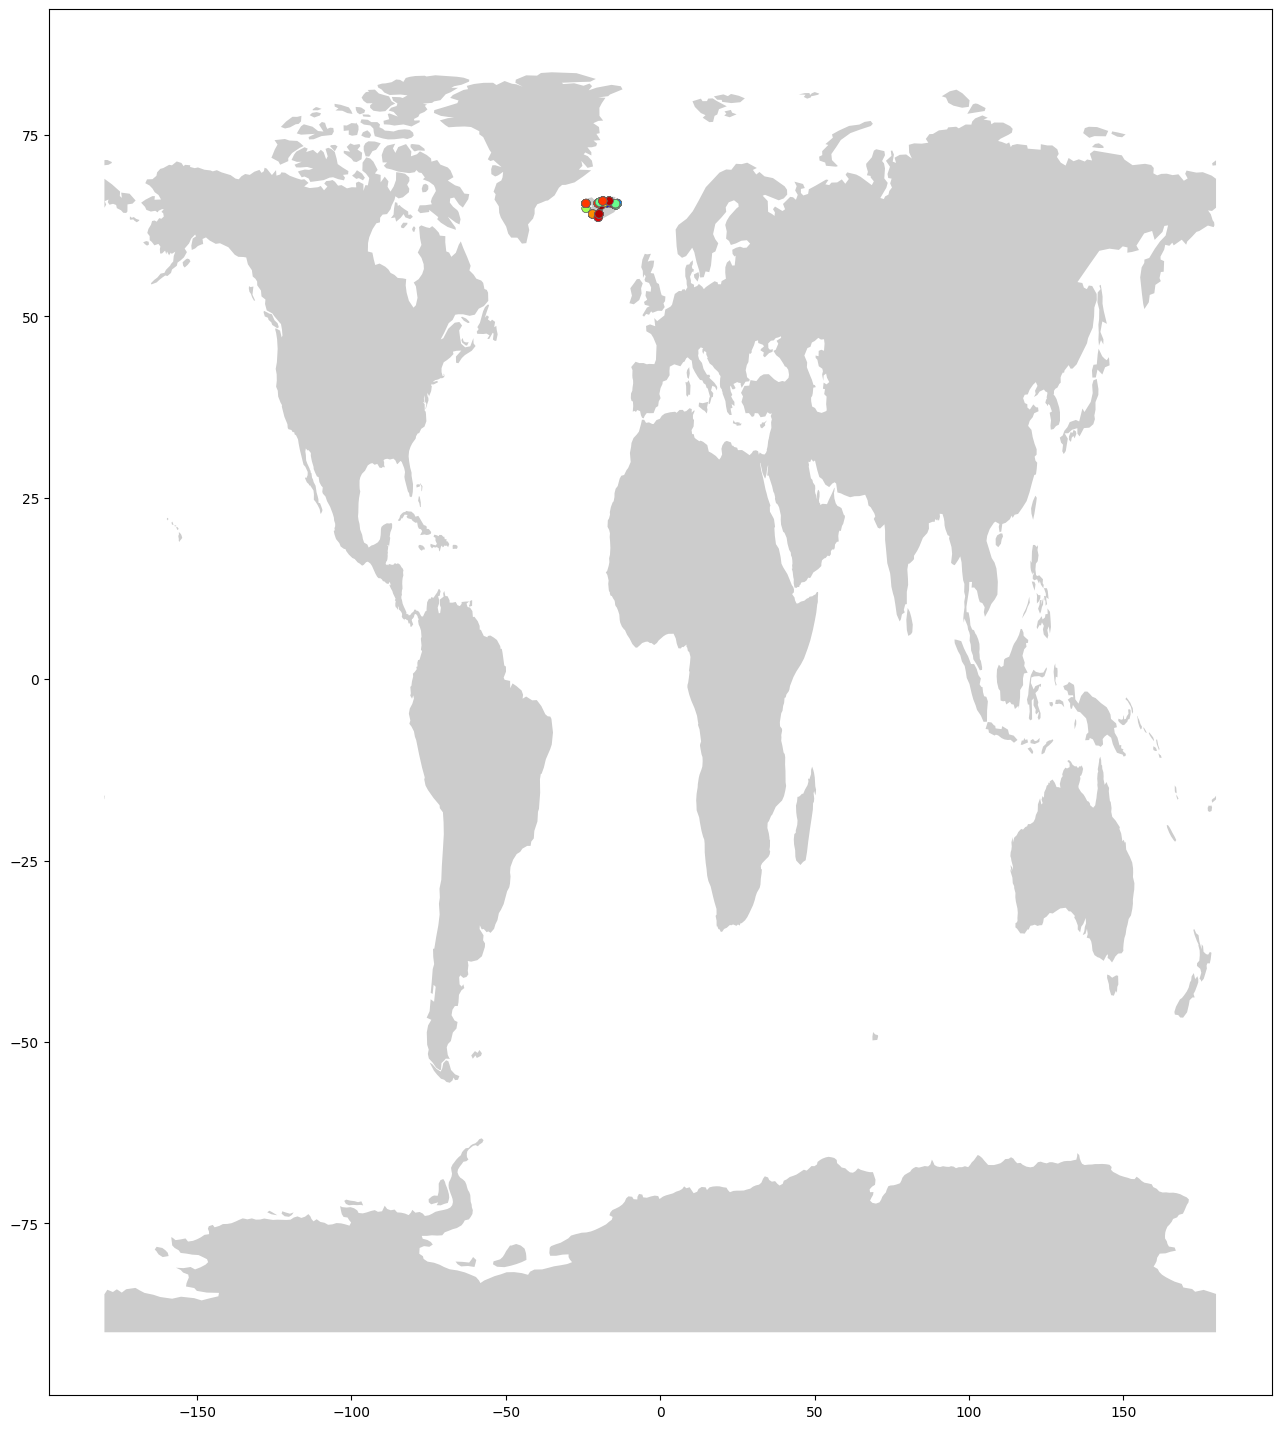

In [21]:
from geodatasets import get_path
import matplotlib.pyplot as plt

world = gpd.read_file(get_path("naturalearth.land"))
# ax = world.plot(color="white", edgecolor="black")
fig, ax = plt.subplots(figsize=(24, 18))
world.plot(ax=ax, alpha=0.4, color="grey")
gdf.plot(ax=ax, column="Dist", cmap="jet", linewidth=0.4, edgecolor=".4")
plt.show()

In [22]:
import matplotlib.pyplot as plt
import geopandas as gpd
from geodatasets import get_path

world = gpd.read_file(get_path("naturalearth.land"))


fig, ax = plt.subplots(figsize=(10,6))
world.plot(ax=ax, color="lightgrey")

sc = ax.scatter(
    gdf["Long."], gdf["Lat."],
    c=gdf["Dist"],
    cmap="jet",
    s=80
)

plt.colorbar(sc, label="Genetic Distance to Iceland Vikings")
#plt.title(f"Genetic Similarity Map — {t}-{t+100} BP")

plt.savefig("modern.png")
plt.close()

In [23]:
Extend_tab

SampleID1,SampleID2,Dist,join_key,Date,Group ID,Lat.,Long.
str,str,f64,str,i64,str,f64,f64
"""DAV-A8""","""DAV-A9""",0.79,"""DAV-A9""",950,"""Iceland_Pre_Christian.SG_son.D…",65.966667,-18.533333
"""DAV-A8""","""DKS-A1""",1.0,"""DKS-A1""",1025,"""Iceland_Pre_Christian.SG""",64.885055,-24.04446
"""DAV-A8""","""FOV-A1""",0.79,"""FOV-A1""",603,"""Iceland_Early_Christian.SG""",65.437602,-14.602639
"""DAV-A8""","""FSS-A1""",0.99,"""FSS-A1""",1015,"""Iceland_Pre_Christian.SG""",65.317,-19.15
"""DAV-A8""","""GRS-A1""",0.99,"""GRS-A1""",1015,"""Iceland_Pre_Christian.SG""",65.642222,-16.120278
…,…,…,…,…,…,…,…
"""VDP-A5""","""VDP-A7""",0.91,"""VDP-A7""",1000,"""Iceland_Pre_Christian.SG""",65.5707,-24.0658
"""VDP-A5""","""YGS-B2""",0.96,"""YGS-B2""",1015,"""Iceland_Pre_Christian.SG""",65.9016,-18.5984
"""VDP-A6""","""VDP-A7""",0.93,"""VDP-A7""",1000,"""Iceland_Pre_Christian.SG""",65.5707,-24.0658


In [24]:
import folium 
from folium import plugins

map = folium.Map(location=[15, 30], tiles="Cartodb dark_matter", zoom_start=2)

heat_data = [
    [point.xy[1][0], point.xy[0][0], dist]
    for point, dist in zip(gdf.geometry, gdf["Dist"])
]

heat_data
plugins.HeatMap(heat_data, radius=25, blur=20, max_zoom=5).add_to(map)

map.save("Iceland.html")